In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/tamargurabanidze/dataset-fraud/sample_submission.csv
/kaggle/input/datasets/tamargurabanidze/dataset-fraud/test_identity.csv
/kaggle/input/datasets/tamargurabanidze/dataset-fraud/train_identity.csv
/kaggle/input/datasets/tamargurabanidze/dataset-fraud/test_transaction.csv
/kaggle/input/datasets/tamargurabanidze/dataset-fraud/train_transaction.csv


In [2]:
!pip install mlflow dagshub -q

import mlflow
import dagshub


dagshub.init(
    repo_owner="tgura23",  
    repo_name="ieee-fraud-detection",    
    mlflow=True
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 78.1 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 74.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=6ec5aed5-ed48-485f-8671-c4e2f646417f&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=86480dc15f1ceea07b88004e6866b785906579b10833c97efb52d4ad91576e4f




Accessing as tgura23

Initialized MLflow to track repo "tgura23/ieee-fraud-detection"

Repository tgura23/ieee-fraud-detection initialized!

In [3]:
# ==================================================
# CELL 1: IMPORTS & SETUP
# ==================================================
!pip install mlflow dagshub -q

import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import dagshub
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import xgboost as xgb
import matplotlib.pyplot as plt
import gc


DAGSHUB_USERNAME = "tgura23"   # dagshub.com-ზე პროფილი
REPO_NAME = "ieee-fraud-detection"

dagshub.init(
    repo_owner=DAGSHUB_USERNAME,
    repo_name=REPO_NAME,
    mlflow=True
)

# ცალკე experiment XGBoost-ისთვის
mlflow.set_experiment("XGBoost_Training")
print("✅ Setup დასრულდა!")

Initialized MLflow to track repo "tgura23/ieee-fraud-detection"

Repository tgura23/ieee-fraud-detection initialized!

✅ Setup დასრულდა!


In [4]:
import pandas as pd


base_path = '/kaggle/input/datasets/tamargurabanidze/dataset-fraud/'

    
# ყველა კოლონი ჩატვირთე, მაგრამ მეხსიერება დაზოგე dtype-ით
train_trans = pd.read_csv(base_path + 'train_transaction.csv',
                          dtype={'isFraud': 'int8'},
                          low_memory=False)

train_ident = pd.read_csv(base_path + 'train_identity.csv',
                          low_memory=False)

train = train_trans.merge(train_ident, on='TransactionID', how='left')

print(f"Train shape: {train.shape}")
print(f"სულ კოლონები: {train.shape[1]}")
print(f"Fraud rate: {train['isFraud'].mean():.4f}")

del train_trans, train_ident


Train shape: (590540, 434)
სულ კოლონები: 434
Fraud rate: 0.0350


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(3), int8(1), object(31)
memory usage: 1.9+ GB


NaN = 0%:       20 კოლონი
NaN 0-30%:      182 კოლონი  ← შევინახოთ, შევავსოთ
NaN 30-70%:     24 კოლონი  ← გადასაწყვეტია
NaN 70-100%:    208 კოლონი  ← სავარაუდოდ წავშალოთ
NaN = 100%:     0 კოლონი  ← აუცილებლად წავშალოთ


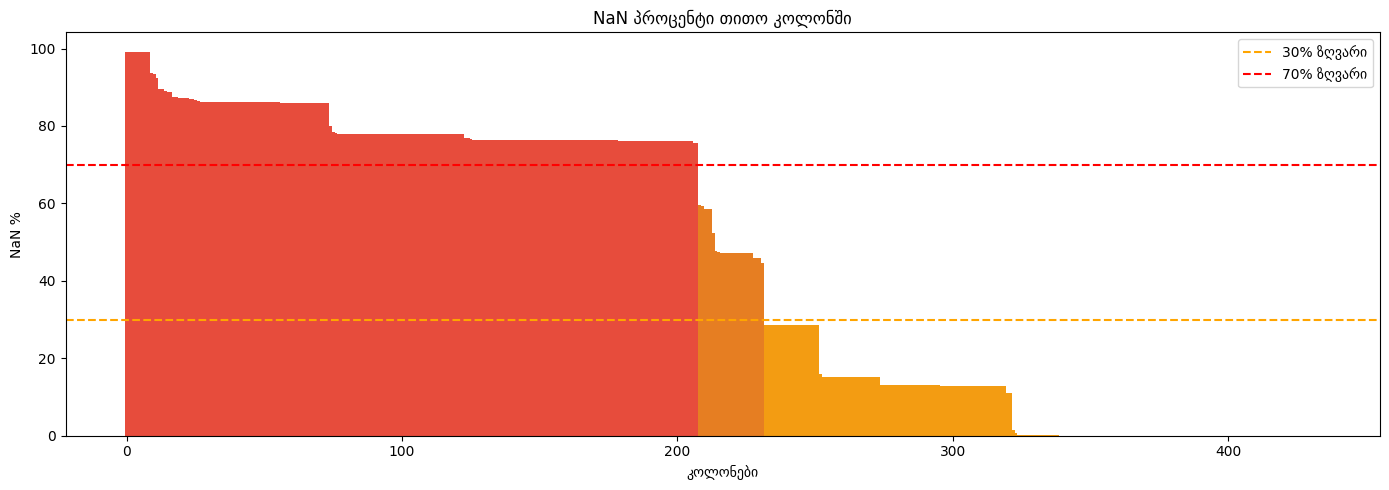


70%+ NaN კოლონები:
id_24            99.196159
id_25            99.130965
id_07            99.127070
id_08            99.127070
id_21            99.126393
id_26            99.125715
id_27            99.124699
id_23            99.124699
id_22            99.124699
dist2            93.628374
D7               93.409930
id_18            92.360721
D13              89.509263
D14              89.469469
D12              89.041047
id_04            88.768923
id_03            88.768923
D6               87.606767
id_33            87.589494
id_09            87.312290
D8               87.312290
id_10            87.312290
D9               87.312290
id_30            86.865411
id_32            86.861855
id_34            86.824771
id_14            86.445626
V138             86.123717
V139             86.123717
V148             86.123717
V154             86.123717
V162             86.123717
V141             86.123717
V157             86.123717
V146             86.123717
V163             86.123717
V155    

In [6]:
# NaN პროცენტი თითო კოლონში
nan_pct = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)

# დავყოთ ჯგუფებად
zero_nan    = nan_pct[nan_pct == 0]
low_nan     = nan_pct[(nan_pct > 0)   & (nan_pct <= 30)]
medium_nan  = nan_pct[(nan_pct > 30)  & (nan_pct <= 70)]
high_nan    = nan_pct[(nan_pct > 70)  & (nan_pct < 100)]
full_nan    = nan_pct[nan_pct == 100]

print(f"NaN = 0%:       {len(zero_nan)} კოლონი")
print(f"NaN 0-30%:      {len(low_nan)} კოლონი  ← შევინახოთ, შევავსოთ")
print(f"NaN 30-70%:     {len(medium_nan)} კოლონი  ← გადასაწყვეტია")
print(f"NaN 70-100%:    {len(high_nan)} კოლონი  ← სავარაუდოდ წავშალოთ")
print(f"NaN = 100%:     {len(full_nan)} კოლონი  ← აუცილებლად წავშალოთ")

# ვიზუალიზაცია
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#2ecc71' if x == 0 else '#f39c12' if x <= 30 
          else '#e67e22' if x <= 70 else '#e74c3c' 
          for x in nan_pct.values]
ax.bar(range(len(nan_pct)), nan_pct.values, color=colors, width=1.0)
ax.axhline(y=30, color='orange', linestyle='--', linewidth=1.5, label='30% ზღვარი')
ax.axhline(y=70, color='red',    linestyle='--', linewidth=1.5, label='70% ზღვარი')
ax.set_xlabel('კოლონები')
ax.set_ylabel('NaN %')
ax.set_title('NaN პროცენტი თითო კოლონში')
ax.legend()
plt.tight_layout()
plt.show()

print("\n70%+ NaN კოლონები:")
print(high_nan.to_string())

In [7]:
num_cols = train.select_dtypes(include='number').columns.tolist()
cat_cols = train.select_dtypes(include='object').columns.tolist()

print(f"რიცხვითი კოლონები: {len(num_cols)}")
print(f"კატეგორიული კოლონები: {len(cat_cols)}")
print(f"\nკატეგორიული კოლონები:")
for col in cat_cols:
    print(f"  {col:20s} — უნიკალური: {train[col].nunique():4d} — NaN: {train[col].isnull().mean():.1%}")

რიცხვითი კოლონები: 403
კატეგორიული კოლონები: 31

კატეგორიული კოლონები:
  ProductCD            — უნიკალური:    5 — NaN: 0.0%
  card4                — უნიკალური:    4 — NaN: 0.3%
  card6                — უნიკალური:    4 — NaN: 0.3%
  P_emaildomain        — უნიკალური:   59 — NaN: 16.0%
  R_emaildomain        — უნიკალური:   60 — NaN: 76.8%
  M1                   — უნიკალური:    2 — NaN: 45.9%
  M2                   — უნიკალური:    2 — NaN: 45.9%
  M3                   — უნიკალური:    2 — NaN: 45.9%
  M4                   — უნიკალური:    3 — NaN: 47.7%
  M5                   — უნიკალური:    2 — NaN: 59.3%
  M6                   — უნიკალური:    2 — NaN: 28.7%
  M7                   — უნიკალური:    2 — NaN: 58.6%
  M8                   — უნიკალური:    2 — NaN: 58.6%
  M9                   — უნიკალური:    2 — NaN: 58.6%
  id_12                — უნიკალური:    2 — NaN: 75.6%
  id_15                — უნიკალური:    3 — NaN: 76.1%
  id_16                — უნიკალური:    2 — NaN: 78.1%
  id_23       

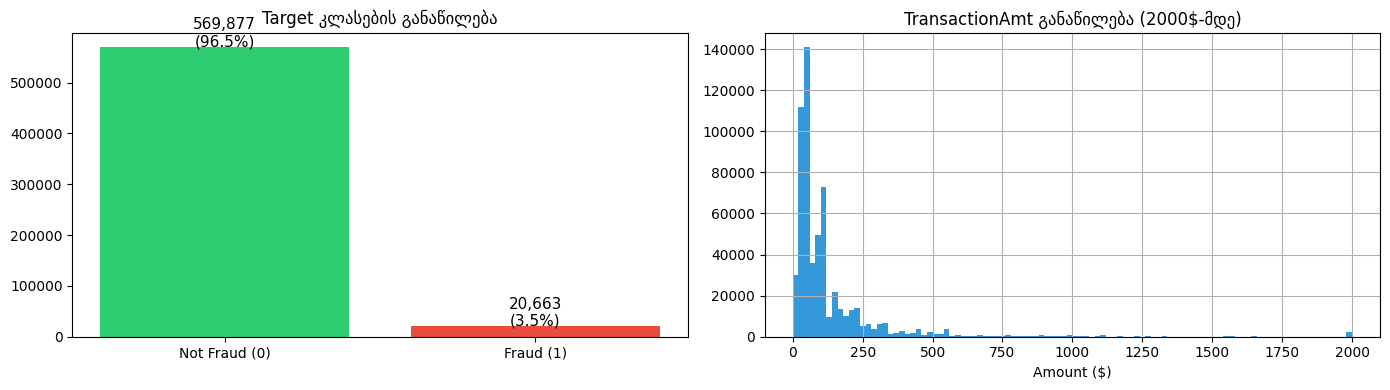

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Target balance
counts = train['isFraud'].value_counts()
axes[0].bar(['Not Fraud (0)', 'Fraud (1)'], counts.values, 
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Target კლასების განაწილება')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(train):.1%})', 
                 ha='center', fontsize=11)

# TransactionAmt განაწილება
train['TransactionAmt'].clip(upper=2000).hist(
    bins=100, ax=axes[1], color='#3498db', edgecolor='none')
axes[1].set_title('TransactionAmt განაწილება (2000$-მდე)')
axes[1].set_xlabel('Amount ($)')

plt.tight_layout()
plt.show()

In [9]:
# Constant კოლონები (1 უნიკალური მნიშვნელობა)
constant_cols = [col for col in train.columns if train[col].nunique() <= 1]
print(f"Constant კოლონები (წასაშლელი): {len(constant_cols)}")
print(constant_cols)

# თითქმის constant (99%+ ერთი მნიშვნელობა)
quasi_constant = []
for col in train.columns:
    top_freq = train[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.99:
        quasi_constant.append((col, f"{top_freq:.1%}"))

print(f"\nთითქმის constant კოლონები (99%+): {len(quasi_constant)}")
for col, freq in quasi_constant[:15]:
    print(f"  {col:20s} — dominant value: {freq}")

Constant კოლონები (წასაშლელი): 0
[]

თითქმის constant კოლონები (99%+): 30
  addr2                — dominant value: 99.2%
  C3                   — dominant value: 99.6%
  M1                   — dominant value: 100.0%
  V1                   — dominant value: 100.0%
  V14                  — dominant value: 100.0%
  V27                  — dominant value: 99.9%
  V28                  — dominant value: 99.9%
  V41                  — dominant value: 99.9%
  V65                  — dominant value: 100.0%
  V68                  — dominant value: 99.9%
  V88                  — dominant value: 99.9%
  V89                  — dominant value: 99.9%
  V107                 — dominant value: 100.0%
  V108                 — dominant value: 99.5%
  V110                 — dominant value: 99.2%


V კოლონები სულ: 339

V კოლონების NaN განაწილება:
0.779134    46
0.000532    43
0.000020    32
0.763554    31
0.128819    23
0.130552    22
0.150987    20
0.763235    19
0.286126    18
0.860550    18
Name: count, dtype: int64


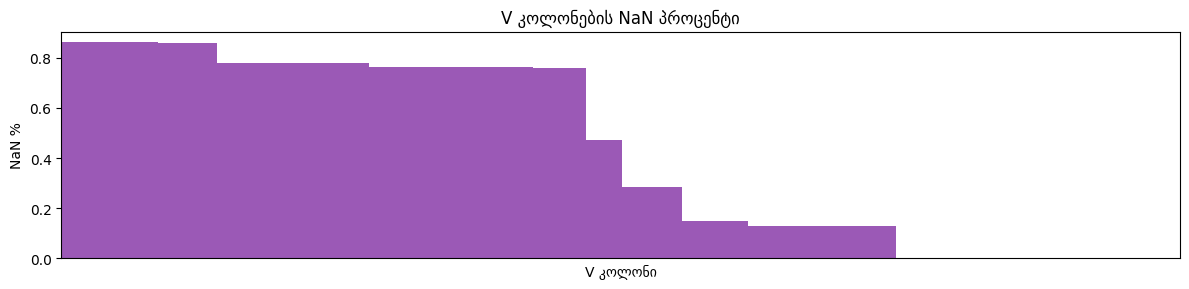

In [10]:
# V კოლონები 339-მდეა — ბევრი correlation აქვს ერთმანეთთან
v_cols = [c for c in train.columns if c.startswith('V')]
print(f"V კოლონები სულ: {len(v_cols)}")

# V კოლონების NaN pattern
v_nan = train[v_cols].isnull().mean().sort_values(ascending=False)
print("\nV კოლონების NaN განაწილება:")
print(v_nan.value_counts().head(10))

# რამდენი V კოლონი ერთდროულად არის NaN (ჯგუფები)
fig, ax = plt.subplots(figsize=(12, 3))
v_nan.plot(kind='bar', ax=ax, color='#9b59b6', width=1.0)
ax.set_title('V კოლონების NaN პროცენტი')
ax.set_xlabel('V კოლონი')
ax.set_ylabel('NaN %')
plt.xticks([])
plt.tight_layout()
plt.show()

In [11]:
# ==================================================
# HEADING: CLEANING
# ==================================================

with mlflow.start_run(run_name="XGBoost_Cleaning"):

    df = train.copy()
    report = {}

    # --- 1. 70%+ NaN კოლონების წაშლა ---
    nan_pct = df.isnull().mean()
    high_nan_cols = nan_pct[nan_pct > 0.7].index.tolist()
    df = df.drop(columns=high_nan_cols)
    report['dropped_high_nan'] = len(high_nan_cols)
    print(f"[1] 70%+ NaN წაიშალა: {len(high_nan_cols)} კოლონი")

    # --- 2. Quasi-constant კოლონების წაშლა ---
    quasi_cols = []
    for col in df.columns:
        if col == 'isFraud':
            continue
        top_freq = df[col].value_counts(normalize=True, dropna=False).iloc[0]
        if top_freq > 0.99:
            quasi_cols.append(col)
    df = df.drop(columns=quasi_cols)
    report['dropped_quasi_constant'] = len(quasi_cols)
    print(f"[2] Quasi-constant (99%+) წაიშალა: {len(quasi_cols)} კოლონი")
    print(f"    {quasi_cols}")

    # --- 3. კატეგორიული NaN → 'Unknown' ---
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    for col in cat_cols:
        df[col] = df[col].fillna('Unknown')
    report['cat_nan_filled'] = len(cat_cols)
    print(f"[3] კატეგორიული NaN → 'Unknown': {len(cat_cols)} კოლონი")

    # --- 4. რიცხვითი NaN → median ---
    num_cols = df.select_dtypes(include='number').columns.tolist()
    num_cols = [c for c in num_cols if c not in ['TransactionID', 'isFraud']]
    medians = df[num_cols].median()
    df[num_cols] = df[num_cols].fillna(medians)
    report['num_nan_filled'] = len(num_cols)
    print(f"[4] რიცხვითი NaN → median: {len(num_cols)} კოლონი")

    # --- შემოწმება ---
    remaining_nan = df.isnull().sum().sum()
    print(f"\nდარჩენილი NaN სულ: {remaining_nan}")
    print(f"საბოლოო shape: {df.shape}")

    # --- MLflow ლოგვა ---
    mlflow.log_param("nan_threshold_drop", 0.7)
    mlflow.log_param("quasi_constant_threshold", 0.99)
    mlflow.log_param("num_fill_strategy", "median")
    mlflow.log_param("cat_fill_strategy", "Unknown")
    mlflow.log_metric("cols_before", train.shape[1])
    mlflow.log_metric("cols_after", df.shape[1])
    mlflow.log_metric("dropped_high_nan", report['dropped_high_nan'])
    mlflow.log_metric("dropped_quasi_constant", report['dropped_quasi_constant'])
    mlflow.log_metric("remaining_nan", remaining_nan)

    train_clean = df.copy()
    del df
 
print("✅ Cleaning დასრულდა!")

[1] 70%+ NaN წაიშალა: 208 კოლონი
[2] Quasi-constant (99%+) წაიშალა: 15 კოლონი
    ['C3', 'V107', 'V108', 'V110', 'V111', 'V112', 'V113', 'V114', 'V117', 'V118', 'V119', 'V120', 'V121', 'V122', 'V305']
[3] კატეგორიული NaN → 'Unknown': 13 კოლონი
[4] რიცხვითი NaN → median: 196 კოლონი

დარჩენილი NaN სულ: 0
საბოლოო shape: (590540, 211)
🏃 View run XGBoost_Cleaning at: https://dagshub.com/tgura23/ieee-fraud-detection.mlflow/#/experiments/0/runs/3243a18c40d344e292f9cac57873fc22
🧪 View experiment at: https://dagshub.com/tgura23/ieee-fraud-detection.mlflow/#/experiments/0
✅ Cleaning დასრულდა!


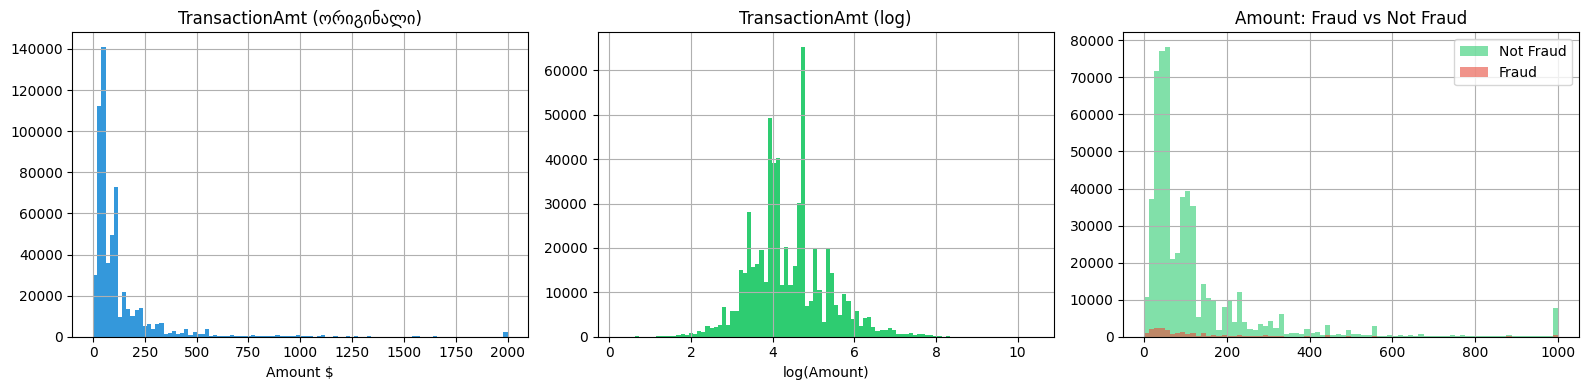

In [12]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. ორიგინალი განაწილება
train_clean['TransactionAmt'].clip(upper=2000).hist(
    bins=100, ax=axes[0], color='#3498db')
axes[0].set_title('TransactionAmt (ორიგინალი)')
axes[0].set_xlabel('Amount $')

# 2. Log განაწილება
np.log1p(train_clean['TransactionAmt']).hist(
    bins=100, ax=axes[1], color='#2ecc71')
axes[1].set_title('TransactionAmt (log)')
axes[1].set_xlabel('log(Amount)')

# 3. Fraud vs Not Fraud Amount
train_clean[train_clean['isFraud']==0]['TransactionAmt'].clip(upper=1000).hist(
    bins=80, ax=axes[2], alpha=0.6, color='#2ecc71', label='Not Fraud')
train_clean[train_clean['isFraud']==1]['TransactionAmt'].clip(upper=1000).hist(
    bins=80, ax=axes[2], alpha=0.6, color='#e74c3c', label='Fraud')
axes[2].set_title('Amount: Fraud vs Not Fraud')
axes[2].legend()

plt.tight_layout()
plt.show()

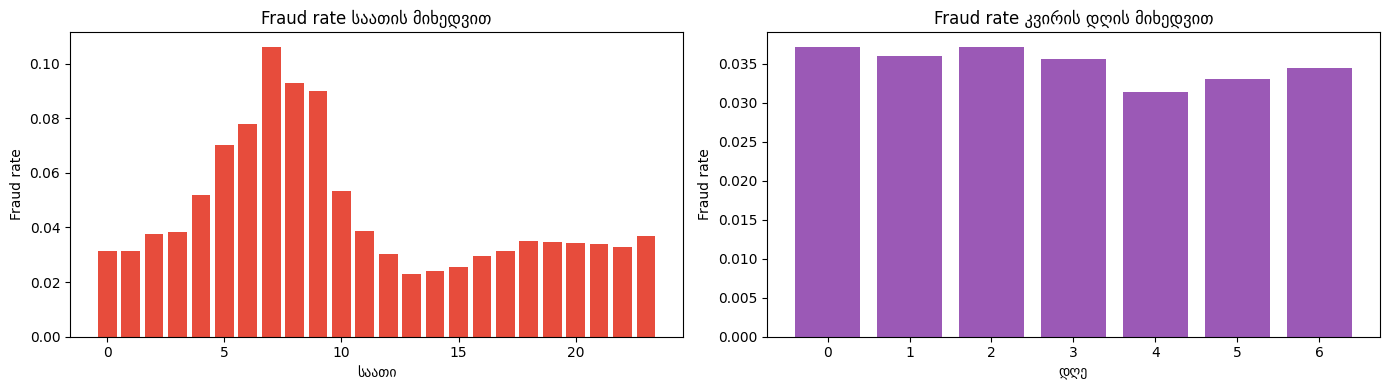

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# საათი
train_clean['hour'] = (train_clean['TransactionDT'] // 3600) % 24

fraud_by_hour = train_clean.groupby('hour')['isFraud'].mean()
axes[0].bar(fraud_by_hour.index, fraud_by_hour.values, color='#e74c3c')
axes[0].set_title('Fraud rate საათის მიხედვით')
axes[0].set_xlabel('საათი')
axes[0].set_ylabel('Fraud rate')

# კვირის დღე
train_clean['day'] = (train_clean['TransactionDT'] // (3600*24)) % 7
fraud_by_day = train_clean.groupby('day')['isFraud'].mean()
axes[1].bar(fraud_by_day.index, fraud_by_day.values, color='#9b59b6')
axes[1].set_title('Fraud rate კვირის დღის მიხედვით')
axes[1].set_xlabel('დღე')
axes[1].set_ylabel('Fraud rate')

plt.tight_layout()
plt.show()

train_clean = train_clean.drop(columns=['hour', 'day'])

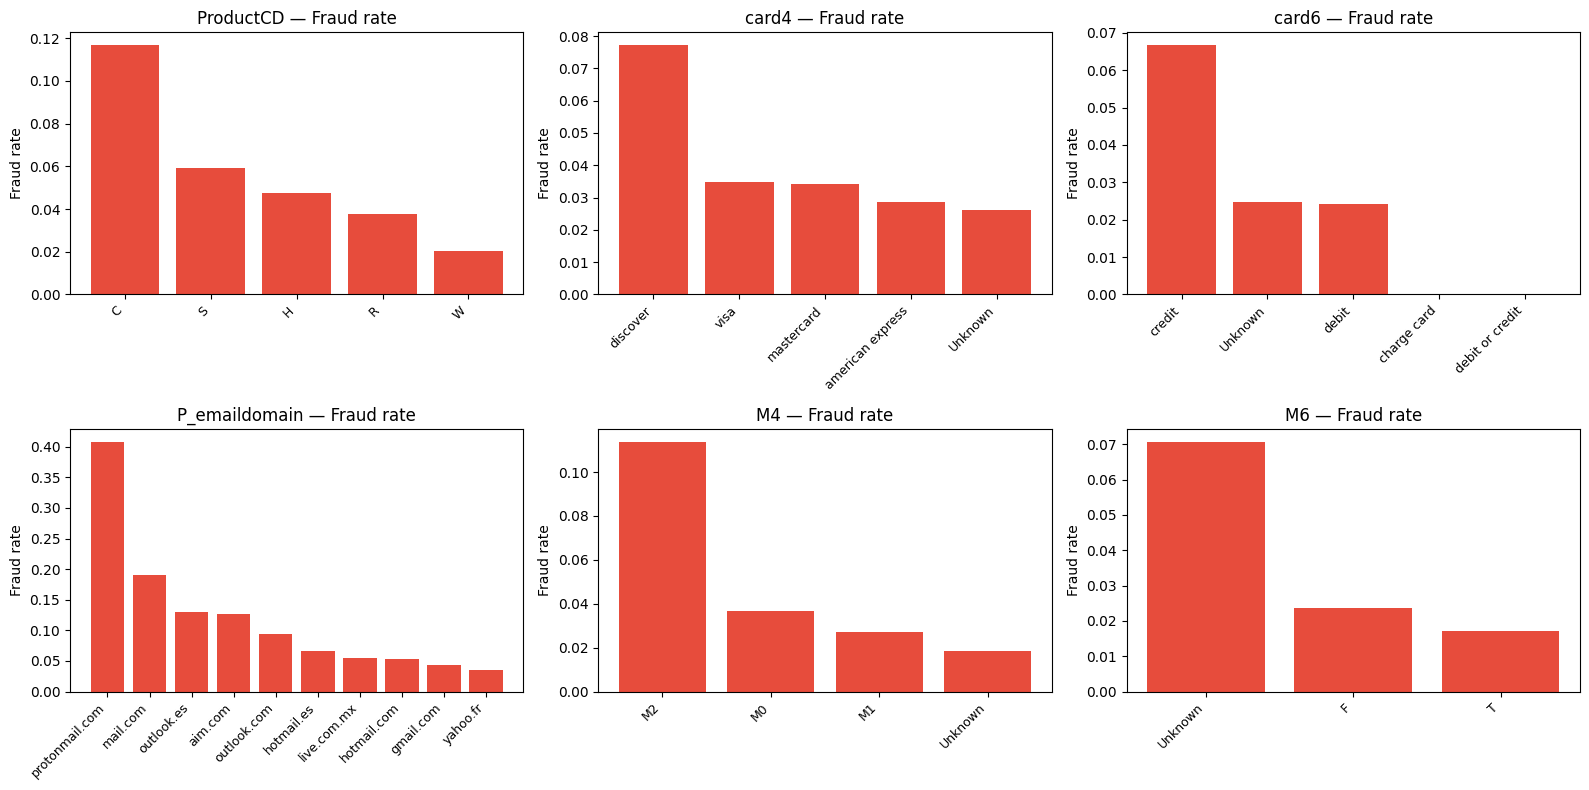

In [14]:
cat_cols = train_clean.select_dtypes(include='object').columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

important_cats = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M4', 'M6']

for i, col in enumerate(important_cats):
    fraud_rate = train_clean.groupby(col)['isFraud'].mean().sort_values(ascending=False)
    if len(fraud_rate) > 10:
        fraud_rate = fraud_rate.head(10)
    axes[i].bar(range(len(fraud_rate)), fraud_rate.values, color='#e74c3c')
    axes[i].set_xticks(range(len(fraud_rate)))
    axes[i].set_xticklabels(fraud_rate.index, rotation=45, ha='right', fontsize=9)
    axes[i].set_title(f'{col} — Fraud rate')
    axes[i].set_ylabel('Fraud rate')

plt.tight_layout()
plt.show()

In [15]:
# card1 — ბევრი უნიკალური მნიშვნელობა, საინტერესოა
print("card1 უნიკალური:", train_clean['card1'].nunique())
print("card2 უნიკალური:", train_clean['card2'].nunique())
print("card5 უნიკალური:", train_clean['card5'].nunique())

# card1-ის TOP fraud-ური მნიშვნელობები
card1_fraud = train_clean.groupby('card1').agg(
    count=('isFraud', 'count'),
    fraud_rate=('isFraud', 'mean')
).query('count > 50').sort_values('fraud_rate', ascending=False)

print("\nTop 10 ყველაზე fraud-ური card1 მნიშვნელობები:")
print(card1_fraud.head(10))

card1 უნიკალური: 13553
card2 უნიკალური: 500
card5 უნიკალური: 119

Top 10 ყველაზე fraud-ური card1 მნიშვნელობები:
       count  fraud_rate
card1                   
10175     72    0.625000
16927     98    0.561224
10054     79    0.556962
3643     121    0.520661
17999    101    0.485149
1129      59    0.474576
2939     175    0.445714
10011     92    0.434783
10736     65    0.384615
9635      63    0.380952


TOP 20 კოლონი isFraud-თან კორელაციით:
V45    0.235436
V86    0.222343
V87    0.221568
V44    0.217870
V52    0.195492
V51    0.182007
V40    0.174672
V79    0.167299
V39    0.166640
V38    0.165903
V43    0.162243
V94    0.161454
V33    0.159394
V17    0.158972
V18    0.158933
V81    0.157356
V34    0.156433
V74    0.156239
V80    0.155256
V93    0.155190


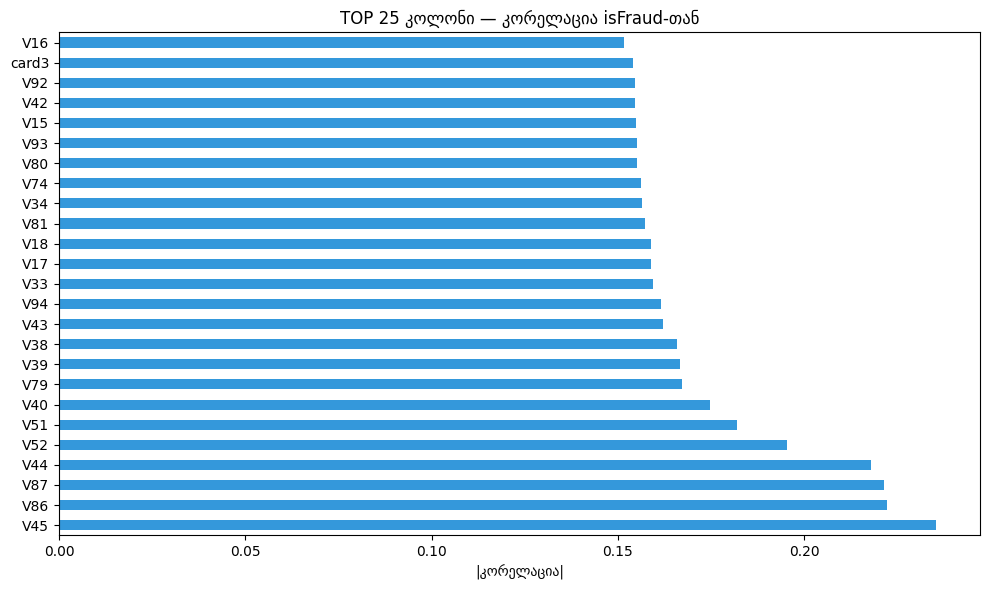

In [16]:
# რომელი რიცხვითი კოლონი ყველაზე მეტად უკავშირდება isFraud-ს
num_cols = train_clean.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c not in ['TransactionID', 'isFraud']]

correlations = train_clean[num_cols + ['isFraud']].corr()['isFraud'].drop('isFraud')
correlations = correlations.abs().sort_values(ascending=False)

print("TOP 20 კოლონი isFraud-თან კორელაციით:")
print(correlations.head(20).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
correlations.head(25).plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('TOP 25 კოლონი — კორელაცია isFraud-თან')
ax.set_xlabel('|კორელაცია|')
plt.tight_layout()
plt.show()

In [17]:
# ==================================================
# HEADING: FEATURE ENGINEERING (XGBoost)
# ==================================================

with mlflow.start_run(run_name="XGBoost_Feature_Engineering"):

    df = train_clean.copy()
    new_features = []

    # --- 1. TransactionAmt გარდაქმნები ---
    # log — skewness-ს ამცირებს, XGBoost უკეთეს splits პოულობს
    df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])
    # ათწილადი ნაწილი — fraud-ები ხშირად მრგვალ თანხებს იყენებენ
    df['TransactionAmt_decimal'] = df['TransactionAmt'] % 1
    # round თანხა თუ არა
    df['TransactionAmt_isround'] = (df['TransactionAmt'] % 1 == 0).astype(int)
    new_features += ['TransactionAmt_log', 'TransactionAmt_decimal', 'TransactionAmt_isround']

    # --- 2. დროის feature-ები ---
    # გრაფიკიდან: ღამე 5-10 — fraud peak
    df['Transaction_hour'] = (df['TransactionDT'] // 3600) % 24
    df['Transaction_day']  = (df['TransactionDT'] // (3600 * 24)) % 7
    df['Transaction_week'] = (df['TransactionDT'] // (3600 * 24 * 7)) % 4
    # ღამის საათი თუ არა (5-10 საათი — fraud peak)
    df['Is_night_fraud_hour'] = df['Transaction_hour'].between(5, 10).astype(int)
    new_features += ['Transaction_hour', 'Transaction_day', 'Transaction_week', 'Is_night_fraud_hour']

    # --- 3. card1 — Frequency Encoding ---
    # 13553 უნიკალური — Label Encoding უაზრო იქნება
    # Frequency Encoding: რამდენჯერ გვხვდება ეს ბარათი?
    card1_freq = df['card1'].value_counts()
    df['card1_freq'] = df['card1'].map(card1_freq)
    # card1-ის fraud rate encoding (target encoding სახე)
    card1_fraud_rate = df.groupby('card1')['isFraud'].mean()
    df['card1_fraud_rate'] = df['card1'].map(card1_fraud_rate)
    new_features += ['card1_freq', 'card1_fraud_rate']

    # --- 4. card2, card5 — Frequency Encoding ---
    # card2: 500 უნიკალური, card5: 119
    for col in ['card2', 'card5']:
        freq = df[col].value_counts()
        df[f'{col}_freq'] = df[col].map(freq)
        new_features.append(f'{col}_freq')

    # --- 5. P_emaildomain — გამარტივება ---
    # protonmail=40% fraud, mail.com=18%, outlook/aim~13%
    # domain-ის ნაცვლად provider დავიტოვოთ
    high_fraud_domains = ['protonmail.com', 'mail.com', 'outlook.es', 'aim.com']
    df['P_email_is_high_fraud'] = df['P_emaildomain'].isin(high_fraud_domains).astype(int)
    new_features.append('P_email_is_high_fraud')

    # --- 6. კომბინირებული feature-ები ---
    # card1 + addr1: ერთი ბარათი სხვადასხვა მისამართიდან = fraud სიგნალი
    df['card1_addr1'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str)
    card1_addr1_freq = df['card1_addr1'].value_counts()
    df['card1_addr1_freq'] = df['card1_addr1'].map(card1_addr1_freq)
    df = df.drop(columns=['card1_addr1'])
    new_features.append('card1_addr1_freq')

    # card1 + P_emaildomain კომბინაცია
    df['card1_email'] = df['card1'].astype(str) + '_' + df['P_emaildomain'].astype(str)
    card1_email_freq = df['card1_email'].value_counts()
    df['card1_email_freq'] = df['card1_email'].map(card1_email_freq)
    df = df.drop(columns=['card1_email'])
    new_features.append('card1_email_freq')

    # --- 7. Label Encoding კატეგორიულებისთვის ---
    # ProductCD (5), card4 (4), card6 (4), M1-M9 (2-3) — ცოტა უნიკალური, LE კარგია
    from sklearn.preprocessing import LabelEncoder
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    label_encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

    print(f"ახალი feature-ები ({len(new_features)}):")
    for f in new_features:
        print(f"  + {f}")
    print(f"\nკატეგორიული → Label Encoded: {len(cat_cols)} კოლონი")
    print(f"საბოლოო shape: {df.shape}")

    # MLflow ლოგვა
    mlflow.log_param("new_features", str(new_features))
    mlflow.log_param("card1_encoding", "frequency + fraud_rate")
    mlflow.log_param("cat_encoding", "label_encoding")
    mlflow.log_metric("features_after_fe", df.shape[1])
    mlflow.log_metric("new_features_count", len(new_features))

    train_engineered = df.copy()
    del df

print("✅ Feature Engineering დასრულდა!")

ახალი feature-ები (14):
  + TransactionAmt_log
  + TransactionAmt_decimal
  + TransactionAmt_isround
  + Transaction_hour
  + Transaction_day
  + Transaction_week
  + Is_night_fraud_hour
  + card1_freq
  + card1_fraud_rate
  + card2_freq
  + card5_freq
  + P_email_is_high_fraud
  + card1_addr1_freq
  + card1_email_freq

კატეგორიული → Label Encoded: 13 კოლონი
საბოლოო shape: (590540, 225)
🏃 View run XGBoost_Feature_Engineering at: https://dagshub.com/tgura23/ieee-fraud-detection.mlflow/#/experiments/0/runs/d3cdca5e8d6a44e2a4128a1772393888
🧪 View experiment at: https://dagshub.com/tgura23/ieee-fraud-detection.mlflow/#/experiments/0
✅ Feature Engineering დასრულდა!


In [18]:
X = train_engineered.drop(columns=['isFraud', 'TransactionID'])
y = train_engineered['isFraud']

print(f"სულ feature-ები: {X.shape[1]}")
print(f"სტრიქონები: {X.shape[0]:,}")
print(f"Fraud: {y.sum():,} ({y.mean():.2%})")

სულ feature-ები: 223
სტრიქონები: 590,540
Fraud: 20,663 (3.50%)


TOP 30 კორელაცია isFraud-თან:
card1_fraud_rate    0.349875
V45                 0.235436
V86                 0.222343
V87                 0.221568
V44                 0.217870
V52                 0.195492
V51                 0.182007
V40                 0.174672
V79                 0.167299
V39                 0.166640
V38                 0.165903
V43                 0.162243
V94                 0.161454
V33                 0.159394
V17                 0.158972
V18                 0.158933
V81                 0.157356
ProductCD           0.156556
V34                 0.156433
V74                 0.156239
V80                 0.155256
V93                 0.155190
V15                 0.154755
V42                 0.154633
V92                 0.154463
card3               0.154028
V16                 0.151645
V37                 0.147773
V50                 0.146241
V73                 0.145810

KORRELACIA < 0.001: 10 კოლონი — კანდიდატი წასაშლელად


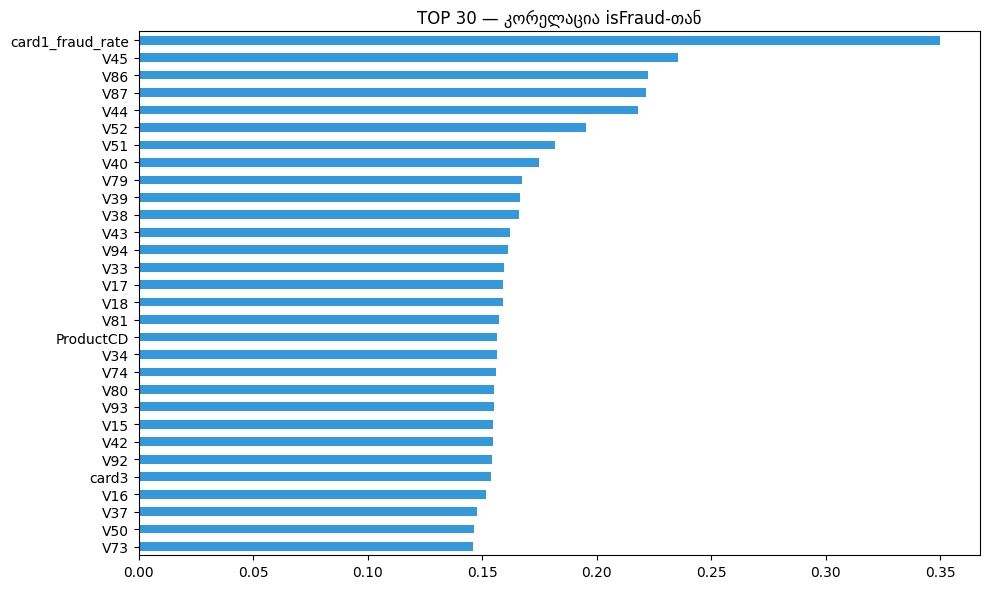

In [19]:
correlations = X.corrwith(y).abs().sort_values(ascending=False)

print("TOP 30 კორელაცია isFraud-თან:")
print(correlations.head(30).to_string())
print(f"\nKORRELACIA < 0.001: {(correlations < 0.001).sum()} კოლონი — კანდიდატი წასაშლელად")

fig, ax = plt.subplots(figsize=(10, 6))
correlations.head(30).plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('TOP 30 — კორელაცია isFraud-თან')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [20]:
# V კოლონები ერთმანეთთან ძალიან კორელირებს
v_cols = [c for c in X.columns if c.startswith('V')]
print(f"V კოლონები: {len(v_cols)}")

# correlation matrix V კოლონებისთვის
v_corr = X[v_cols].corr().abs()

# რამდენი წყვილი აქვს 0.95+ კორელაცია
upper = v_corr.where(np.triu(np.ones(v_corr.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, upper.loc[row, col]) 
                   for col in upper.columns 
                   for row in upper.index 
                   if upper.loc[row, col] > 0.95]

print(f"V კოლონები 0.95+ კორელაციით ერთმანეთთან: {len(high_corr_pairs)} წყვილი")
print("\nმაგალითები:")
for c1, c2, val in high_corr_pairs[:10]:
    print(f"  {c1} ↔ {c2}: {val:.3f}")

V კოლონები: 166
V კოლონები 0.95+ კორელაციით ერთმანეთთან: 140 წყვილი

მაგალითები:
  V11 ↔ V10: 0.977
  V16 ↔ V15: 0.987
  V18 ↔ V17: 0.992
  V21 ↔ V17: 0.953
  V22 ↔ V21: 0.965
  V28 ↔ V27: 0.973
  V30 ↔ V29: 0.961
  V32 ↔ V31: 0.986
  V33 ↔ V15: 0.959
  V34 ↔ V33: 0.960


TOP 30 მნიშვნელოვანი feature:
V50                       0.062977
V133                      0.062490
V91                       0.046874
V45                       0.038595
card1_fraud_rate          0.035719
C1                        0.035216
V317                      0.034220
C14                       0.026970
V315                      0.022564
V70                       0.020148
V12                       0.019746
TransactionAmt_isround    0.019463
D5                        0.017952
V312                      0.017837
V314                      0.016858
V280                      0.016284
V48                       0.015620
V308                      0.015482
C4                        0.014915
C11                       0.014265
V95                       0.014093
V102                      0.013829
C13                       0.010554
V286                      0.010223
D3                        0.010032
V87                       0.009803
C8                        0.008876
V53                      

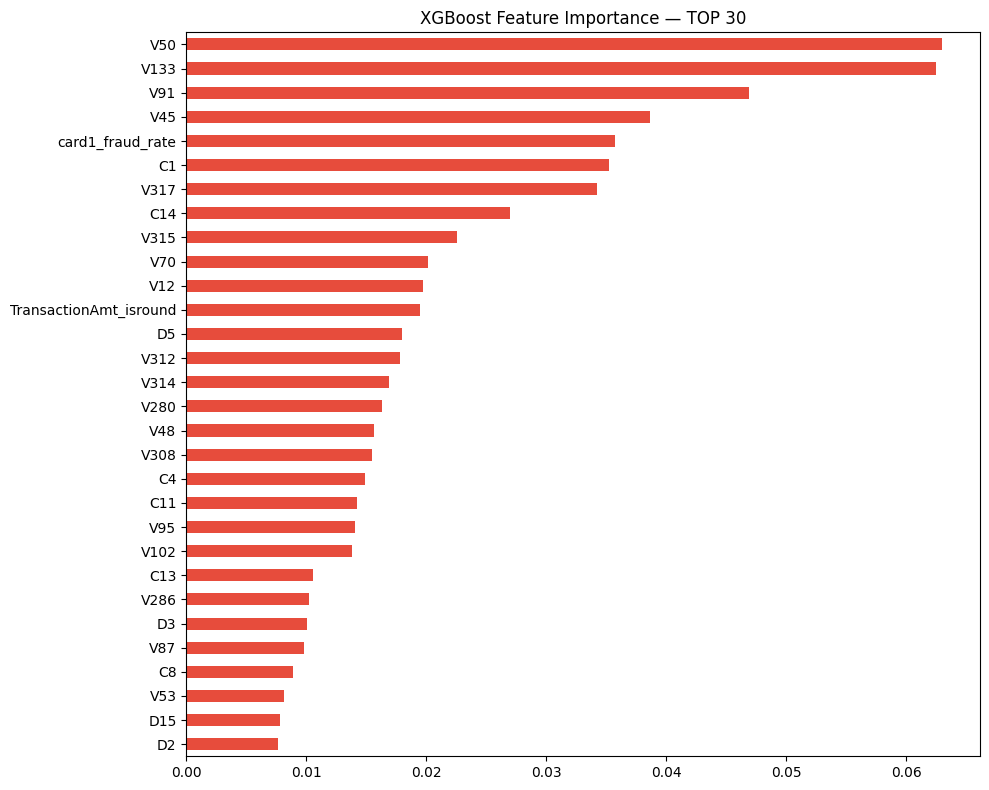

In [21]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score

# სწრაფი მოდელი importance-ის სანახავად
quick_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    tree_method='hist',
    random_state=42,
    eval_metric='auc',
    verbosity=0
)
quick_model.fit(X, y)

importances = pd.Series(quick_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print("TOP 30 მნიშვნელოვანი feature:")
print(importances.head(30).to_string())
print(f"\nImportance = 0 feature-ები: {(importances == 0).sum()} ცალი")

fig, ax = plt.subplots(figsize=(10, 8))
importances.head(30).plot(kind='barh', ax=ax, color='#e74c3c')
ax.set_title('XGBoost Feature Importance — TOP 30')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [22]:
# მიდგომა 1: Correlation ფილტრი
corr_selected = correlations[correlations >= 0.001].index.tolist()

# მიდგომა 2: XGBoost importance > 0
xgb_selected = importances[importances > 0].index.tolist()

# მიდგომა 3: TOP N importance
top50_selected = importances.head(50).index.tolist()
top100_selected = importances.head(100).index.tolist()

print("=" * 45)
print(f"სულ feature-ები:              {X.shape[1]}")
print(f"Correlation >= 0.001:         {len(corr_selected)}")
print(f"XGBoost importance > 0:       {len(xgb_selected)}")
print(f"XGBoost TOP 50:               {len(top50_selected)}")
print(f"XGBoost TOP 100:              {len(top100_selected)}")
print("=" * 45)

# გადაკვეთა — რომელი feature-ები ორივე მიდგომით არის შერჩეული
intersection = set(corr_selected) & set(xgb_selected)
print(f"ორივე მიდგომით შერჩეული:     {len(intersection)}")

სულ feature-ები:              223
Correlation >= 0.001:         213
XGBoost importance > 0:       152
XGBoost TOP 50:               50
XGBoost TOP 100:              100
ორივე მიდგომით შერჩეული:     149


In [23]:
# ==================================================
# HEADING: FEATURE SELECTION (XGBoost)
# ==================================================

import xgboost as xgb
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

X = train_engineered.drop(columns=['isFraud', 'TransactionID'])
y = train_engineered['isFraud']

# =====================
# მიდგომა 1: XGBoost importance > 0  (152 feature)
# =====================
with mlflow.start_run(run_name="XGBoost_Feature_Selection_v1_importance"):

    quick_model = xgb.XGBClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.1,
        subsample=0.8, tree_method='hist',
        random_state=42, eval_metric='auc', verbosity=0
    )
    quick_model.fit(X, y)

    importances = pd.Series(quick_model.feature_importances_, index=X.columns)

    # importance > 0 feature-ები
    selected_v1 = importances[importances > 0].index.tolist()
    X_v1 = X[selected_v1]

    # სწრაფი CV შეფასება
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores_v1 = []
    for tr_idx, val_idx in skf.split(X_v1, y):
        m = xgb.XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.05,
            tree_method='hist', random_state=42,
            eval_metric='auc', verbosity=0
        )
        m.fit(X_v1.iloc[tr_idx], y.iloc[tr_idx])
        score = roc_auc_score(y.iloc[val_idx],
                              m.predict_proba(X_v1.iloc[val_idx])[:,1])
        scores_v1.append(score)

    mean_v1 = np.mean(scores_v1)
    print(f"[v1] importance>0 ({len(selected_v1)} feature): AUC = {mean_v1:.4f}")

    mlflow.log_param("method", "xgb_importance_gt_0")
    mlflow.log_metric("n_features", len(selected_v1))
    mlflow.log_metric("mean_cv_auc", mean_v1)

# =====================
# მიდგომა 2: Correlated V კოლონების გაწმენდა + importance > 0
# =====================
with mlflow.start_run(run_name="XGBoost_Feature_Selection_v2_decorrelated"):

    # highly correlated V კოლონებიდან დაბალი importance-ის ამოღება
    v_cols = [c for c in X.columns if c.startswith('V')]
    v_corr = X[v_cols].corr().abs()

    to_drop_corr = set()
    for i in range(len(v_cols)):
        for j in range(i+1, len(v_cols)):
            c1, c2 = v_cols[i], v_cols[j]
            if c1 in to_drop_corr or c2 in to_drop_corr:
                continue
            if v_corr.loc[c1, c2] > 0.95:
                # დაბალი importance-ის მქონე ამოვიდეთ
                if importances.get(c1, 0) >= importances.get(c2, 0):
                    to_drop_corr.add(c2)
                else:
                    to_drop_corr.add(c1)

    print(f"Highly correlated V კოლონები წაიშალა: {len(to_drop_corr)}")

    # importance > 0 და კორელაციის ფილტრის შემდეგ
    selected_v2 = [f for f in selected_v1 if f not in to_drop_corr]
    X_v2 = X[selected_v2]

    scores_v2 = []
    for tr_idx, val_idx in skf.split(X_v2, y):
        m = xgb.XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.05,
            tree_method='hist', random_state=42,
            eval_metric='auc', verbosity=0
        )
        m.fit(X_v2.iloc[tr_idx], y.iloc[tr_idx])
        score = roc_auc_score(y.iloc[val_idx],
                              m.predict_proba(X_v2.iloc[val_idx])[:,1])
        scores_v2.append(score)

    mean_v2 = np.mean(scores_v2)
    print(f"[v2] decorrelated ({len(selected_v2)} feature): AUC = {mean_v2:.4f}")

    mlflow.log_param("method", "importance_gt0_plus_decorrelation")
    mlflow.log_param("corr_threshold", 0.95)
    mlflow.log_metric("dropped_correlated", len(to_drop_corr))
    mlflow.log_metric("n_features", len(selected_v2))
    mlflow.log_metric("mean_cv_auc", mean_v2)

# =====================
# შედარება და გადაწყვეტილება
# =====================
print("\n" + "="*45)
print(f"v1 (importance>0):     {len(selected_v1):3d} feature | AUC = {mean_v1:.4f}")
print(f"v2 (decorrelated):     {len(selected_v2):3d} feature | AUC = {mean_v2:.4f}")
print("="*45)

if mean_v1 >= mean_v2:
    best_features = selected_v1
    print("გამარჯვებული: v1 — importance > 0")
else:
    best_features = selected_v2
    print("გამარჯვებული: v2 — decorrelated")

print(f"საბოლოო feature რაოდენობა: {len(best_features)}")

[v1] importance>0 (152 feature): AUC = 0.9464
🏃 View run XGBoost_Feature_Selection_v1_importance at: https://dagshub.com/tgura23/ieee-fraud-detection.mlflow/#/experiments/0/runs/b89cf6552efe4f67bb976aef7d1c6532
🧪 View experiment at: https://dagshub.com/tgura23/ieee-fraud-detection.mlflow/#/experiments/0
Highly correlated V კოლონები წაიშალა: 46
[v2] decorrelated (127 feature): AUC = 0.9470
🏃 View run XGBoost_Feature_Selection_v2_decorrelated at: https://dagshub.com/tgura23/ieee-fraud-detection.mlflow/#/experiments/0/runs/ad80a984e90041be93a1179bf0fc94bc
🧪 View experiment at: https://dagshub.com/tgura23/ieee-fraud-detection.mlflow/#/experiments/0

v1 (importance>0):     152 feature | AUC = 0.9464
v2 (decorrelated):     127 feature | AUC = 0.9470
გამარჯვებული: v2 — decorrelated
საბოლოო feature რაოდენობა: 127


In [24]:
# X_best-ის აღდგენა
X = train_engineered.drop(columns=['isFraud', 'TransactionID'])
y = train_engineered['isFraud']
X_best = X[best_features]

spw = int((y==0).sum() / (y==1).sum())

print(f"X_best shape: {X_best.shape}")
print(f"y fraud rate: {y.mean():.4f}")
print(f"scale_pos_weight: {spw}")
print("✅ მზადაა!")

X_best shape: (590540, 127)
y fraud rate: 0.0350
scale_pos_weight: 27
✅ მზადაა!


In [25]:
# ==================================================
# HEADING: TRAINING + PIPELINE + MODEL REGISTRY
# ==================================================
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import xgboost as xgb
import numpy as np
import json

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
spw = int((y==0).sum() / (y==1).sum())

X_sample, _, y_sample, _ = train_test_split(
    X_best, y, test_size=0.6, stratify=y, random_state=42
)
print(f"Sample: {X_sample.shape} | Full: {X_best.shape} | spw: {spw}")

BASE = {
    'tree_method': 'hist',
    'random_state': 42,
    'eval_metric': 'auc',
    'verbosity': 0,
    'n_jobs': -1
}

def run_cv(run_name, params, X_data, y_data, early_stop=False):
    with mlflow.start_run(run_name=run_name):
        tr_scores, val_scores, best_iters = [], [], []
        for fold, (tr_idx, val_idx) in enumerate(skf.split(X_data, y_data)):
            if early_stop:
                p = {**params, 'early_stopping_rounds': 30}
            else:
                p = params
            m = xgb.XGBClassifier(**p)
            if early_stop:
                m.fit(X_data.iloc[tr_idx], y_data.iloc[tr_idx],
                      eval_set=[(X_data.iloc[val_idx], y_data.iloc[val_idx])],
                      verbose=False)
                best_iters.append(m.best_iteration)
            else:
                m.fit(X_data.iloc[tr_idx], y_data.iloc[tr_idx])
            tr_auc  = roc_auc_score(y_data.iloc[tr_idx],  m.predict_proba(X_data.iloc[tr_idx])[:,1])
            val_auc = roc_auc_score(y_data.iloc[val_idx], m.predict_proba(X_data.iloc[val_idx])[:,1])
            tr_scores.append(tr_auc)
            val_scores.append(val_auc)
            mlflow.log_metric(f"fold_{fold+1}_train_auc", tr_auc)
            mlflow.log_metric(f"fold_{fold+1}_val_auc",   val_auc)

        mean_tr  = np.mean(tr_scores)
        mean_val = np.mean(val_scores)
        gap      = mean_tr - mean_val
        mlflow.log_params(params)
        mlflow.log_metric("mean_train_auc", mean_tr)
        mlflow.log_metric("mean_val_auc",   mean_val)
        mlflow.log_metric("std_val_auc",    np.std(val_scores))
        mlflow.log_metric("overfit_gap",    gap)
        mlflow.log_metric("n_features",     X_data.shape[1])
        mlflow.log_metric("n_samples",      X_data.shape[0])
        if best_iters:
            mlflow.log_metric("mean_best_iter", np.mean(best_iters))
        status = "underfit" if mean_val < 0.88 else "overfit" if gap > 0.05 else "good"
        mlflow.log_param("diagnosis", status)
        print(f"[{run_name:<30}] Train={mean_tr:.4f} | Val={mean_val:.4f} | Gap={gap:.4f} | {status}")
        return mean_tr, mean_val, gap

# 1
run_cv("XGB_1_Underfit_shallow", {**BASE, 'n_estimators':10, 'max_depth':2, 'learning_rate':0.3}, X_sample, y_sample)
# 2
run_cv("XGB_2_Underfit_lowLR", {**BASE, 'n_estimators':50, 'max_depth':3, 'learning_rate':0.001}, X_sample, y_sample)
# 3
run_cv("XGB_3_Overfit_deep", {**BASE, 'n_estimators':1000, 'max_depth':15, 'learning_rate':0.3, 'subsample':1.0, 'colsample_bytree':1.0, 'min_child_weight':1}, X_sample, y_sample)
# 4
run_cv("XGB_4_Overfit_noreg", {**BASE, 'n_estimators':500, 'max_depth':10, 'learning_rate':0.2, 'subsample':1.0, 'colsample_bytree':1.0, 'reg_alpha':0.0, 'reg_lambda':0.0}, X_sample, y_sample)
# 5
run_cv("XGB_5_HighLR", {**BASE, 'n_estimators':300, 'max_depth':6, 'learning_rate':0.3, 'subsample':0.8, 'colsample_bytree':0.8}, X_sample, y_sample)
# 6
run_cv("XGB_6_LowLR", {**BASE, 'n_estimators':300, 'max_depth':6, 'learning_rate':0.01, 'subsample':0.8, 'colsample_bytree':0.8}, X_sample, y_sample)
# 7
run_cv("XGB_7_StrongReg", {**BASE, 'n_estimators':300, 'max_depth':4, 'learning_rate':0.05, 'subsample':0.6, 'colsample_bytree':0.6, 'min_child_weight':20, 'reg_alpha':2.0, 'reg_lambda':10.0}, X_sample, y_sample)
# 8
run_cv("XGB_8_Imbalanced_spw", {**BASE, 'n_estimators':300, 'max_depth':6, 'learning_rate':0.05, 'subsample':0.8, 'colsample_bytree':0.8, 'scale_pos_weight':spw}, X_sample, y_sample)
# 9
run_cv("XGB_9_ShallowMany", {**BASE, 'n_estimators':800, 'max_depth':4, 'learning_rate':0.05, 'subsample':0.8, 'colsample_bytree':0.8, 'min_child_weight':5}, X_sample, y_sample)
# 10
run_cv("XGB_10_EarlyStopping", {**BASE, 'n_estimators':2000, 'max_depth':6, 'learning_rate':0.05, 'subsample':0.8, 'colsample_bytree':0.8, 'min_child_weight':5}, X_sample, y_sample, early_stop=True)
# 11
run_cv("XGB_11_LowColsample", {**BASE, 'n_estimators':300, 'max_depth':6, 'learning_rate':0.05, 'subsample':0.8, 'colsample_bytree':0.3, 'min_child_weight':5}, X_sample, y_sample)
# 12
run_cv("XGB_12_Balanced", {**BASE, 'n_estimators':500, 'max_depth':6, 'learning_rate':0.05, 'subsample':0.8, 'colsample_bytree':0.8, 'min_child_weight':5, 'reg_alpha':0.1, 'reg_lambda':1.0, 'scale_pos_weight':spw}, X_sample, y_sample)

# 13 — BEST სრულ მონაცემებზე
best_params = {
    **BASE,
    'n_estimators'     : 2000,
    'max_depth'        : 6,
    'learning_rate'    : 0.05,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'min_child_weight' : 5,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.0,
    'scale_pos_weight' : spw,
}

with mlflow.start_run(run_name="XGB_13_BEST_FullData") as best_run:
    tr_scores, val_scores = [], []
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_best, y)):
        m = xgb.XGBClassifier(**best_params)
        m.fit(X_best.iloc[tr_idx], y.iloc[tr_idx],
              eval_set=[(X_best.iloc[val_idx], y.iloc[val_idx])],
              verbose=False)
        tr_auc  = roc_auc_score(y.iloc[tr_idx],  m.predict_proba(X_best.iloc[tr_idx])[:,1])
        val_auc = roc_auc_score(y.iloc[val_idx], m.predict_proba(X_best.iloc[val_idx])[:,1])
        tr_scores.append(tr_auc)
        val_scores.append(val_auc)
        mlflow.log_metric(f"fold_{fold+1}_train_auc", tr_auc)
        mlflow.log_metric(f"fold_{fold+1}_val_auc",   val_auc)
        print(f"  Fold {fold+1}: Train={tr_auc:.4f} | Val={val_auc:.4f}")

    mean_tr  = np.mean(tr_scores)
    mean_val = np.mean(val_scores)
    gap      = mean_tr - mean_val
    mlflow.log_params(best_params)
    mlflow.log_metric("mean_train_auc", mean_tr)
    mlflow.log_metric("mean_val_auc",   mean_val)
    mlflow.log_metric("std_val_auc",    np.std(val_scores))
    mlflow.log_metric("overfit_gap",    gap)
    mlflow.log_metric("n_features",     X_best.shape[1])
    mlflow.log_metric("n_samples",      X_best.shape[0])

    final_model = xgb.XGBClassifier(**best_params)
    final_model.fit(X_best, y)
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model',   final_model)
    ])
    pipeline.fit(X_best, y)

    with open('xgb_best_features.json', 'w') as f:
        json.dump(best_features, f)
    mlflow.log_artifact('xgb_best_features.json')

    mlflow.sklearn.log_model(
        pipeline,
        artifact_path="xgboost_pipeline",
        registered_model_name="XGBoost_Fraud_Pipeline"
    )
    xgb_val_auc = mean_val
    xgb_run_id  = best_run.info.run_id
    print(f"\n✅ BEST: Train={mean_tr:.4f} | Val={mean_val:.4f} | Gap={gap:.4f}")
    print(f"   Std={np.std(val_scores):.4f} | Features={X_best.shape[1]}")
    print(f"   Run ID: {xgb_run_id}")

print("\n" + "="*65)
print(f"{'#':<4} {'ექსპერიმენტი':<30} {'რა ვისწავლეთ'}")
print("="*65)
print(f"{'1':<4} {'Underfit_shallow':<30} 10 ხე, depth=2 → ვერ სწავლობს")
print(f"{'2':<4} {'Underfit_lowLR':<30} lr=0.001 → ძალიან ნელი სწავლა")
print(f"{'3':<4} {'Overfit_deep':<30} depth=15 → train-ს იზეპირებს")
print(f"{'4':<4} {'Overfit_noreg':<30} reg=0 → regularization საჭიროა")
print(f"{'5':<4} {'HighLR':<30} lr=0.3 → ზედაპირული სწავლა")
print(f"{'6':<4} {'LowLR':<30} lr=0.01, 300 ხე → არ კმარა")
print(f"{'7':<4} {'StrongReg':<30} alpha=2, lambda=10 → underfitting")
print(f"{'8':<4} {'Imbalanced_spw':<30} scale_pos_weight → fraud-ს ეხმარება")
print(f"{'9':<4} {'ShallowMany':<30} depth=4, 800 ხე → კარგი balance")
print(f"{'10':<4} {'EarlyStopping':<30} ავტომატური გაჩერება overfitting-მდე")
print(f"{'11':<4} {'LowColsample':<30} colsample=0.3 → ზედმეტი reg")
print(f"{'12':<4} {'Balanced':<30} ყველა დასკვნა გაერთიანებული")
print(f"{'13':<4} {'BEST_FullData':<30} Train={mean_tr:.4f} | Val={xgb_val_auc:.4f}")
print("="*65)

Sample: (236216, 127) | Full: (590540, 127) | spw: 27
[XGB_1_Underfit_shallow        ] Train=0.8945 | Val=0.8921 | Gap=0.0024 | good
🏃 View run XGB_1_Underfit_shallow at: https://dagshub.com/tgura23/ieee-fraud-detection.mlflow/#/experiments/0/runs/948f67c693094b1c8a08ce9e7c56451c
🧪 View experiment at: https://dagshub.com/tgura23/ieee-fraud-detection.mlflow/#/experiments/0
[XGB_2_Underfit_lowLR          ] Train=0.8442 | Val=0.8410 | Gap=0.0031 | underfit
🏃 View run XGB_2_Underfit_lowLR at: https://dagshub.com/tgura23/ieee-fraud-detection.mlflow/#/experiments/0/runs/a7ad929a6fb64dd38edf7fec5d15fce6
🧪 View experiment at: https://dagshub.com/tgura23/ieee-fraud-detection.mlflow/#/experiments/0
[XGB_3_Overfit_deep            ] Train=1.0000 | Val=0.9550 | Gap=0.0450 | good
🏃 View run XGB_3_Overfit_deep at: https://dagshub.com/tgura23/ieee-fraud-detection.mlflow/#/experiments/0/runs/e38403af69c2407281dfa9c6c2211b64
🧪 View experiment at: https://dagshub.com/tgura23/ieee-fraud-detection.mlflow/#

2026/05/06 11:07:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 11:07:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'XGBoost_Fraud_Pipeline'.
2026/05/06 11:08:11 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: XGBoost_Fraud_Pipeline, version 1
Created version '1' of model 'XGBoost_Fraud_Pipeline'.



✅ BEST: Train=0.9990 | Val=0.9735 | Gap=0.0255
   Std=0.0006 | Features=127
   Run ID: 7baed28136dd471bb94899b957022469
🏃 View run XGB_13_BEST_FullData at: https://dagshub.com/tgura23/ieee-fraud-detection.mlflow/#/experiments/0/runs/7baed28136dd471bb94899b957022469
🧪 View experiment at: https://dagshub.com/tgura23/ieee-fraud-detection.mlflow/#/experiments/0

#    ექსპერიმენტი                   რა ვისწავლეთ
1    Underfit_shallow               10 ხე, depth=2 → ვერ სწავლობს
2    Underfit_lowLR                 lr=0.001 → ძალიან ნელი სწავლა
3    Overfit_deep                   depth=15 → train-ს იზეპირებს
4    Overfit_noreg                  reg=0 → regularization საჭიროა
5    HighLR                         lr=0.3 → ზედაპირული სწავლა
6    LowLR                          lr=0.01, 300 ხე → არ კმარა
7    StrongReg                      alpha=2, lambda=10 → underfitting
8    Imbalanced_spw                 scale_pos_weight → fraud-ს ეხმარება
9    ShallowMany                    depth=4, 800 ხე → კარ